<a href="https://colab.research.google.com/github/aHawkins63/Feature-Engineering/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

In [ ]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes-1.csv", header=1, names=col_names)

In [ ]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7056277056277056


In [ ]:
pip install six

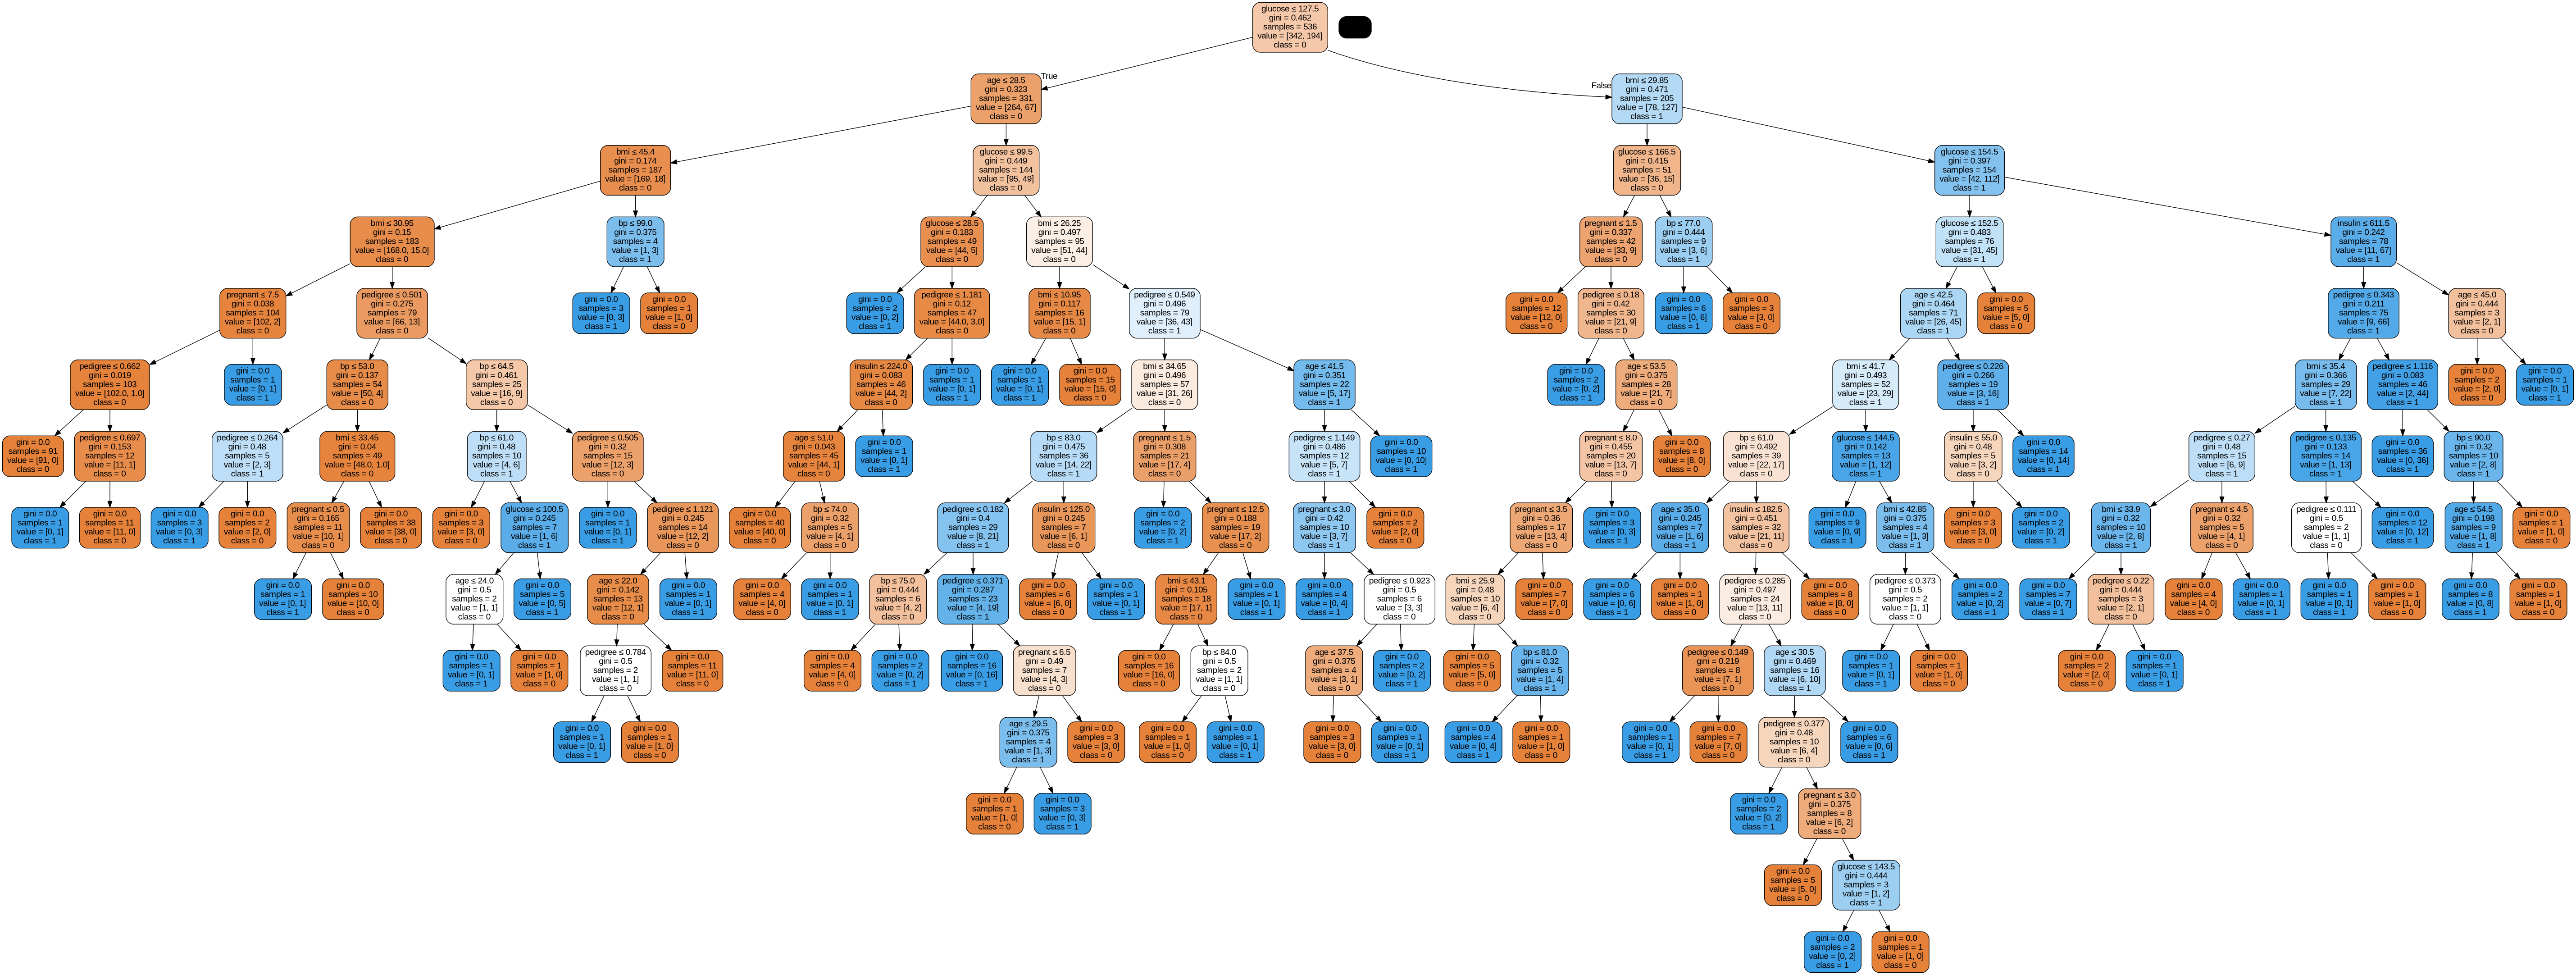

In [ ]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

Optimizing Decision Tree Performance

**criterion :** optional (default=”gini”) or Choose attribute selection measure: This parameter allows us to use the different-different attribute selection measure. Supported criteria are “gini” for the Gini index and “entropy” for the information gain.

**splitter :** string, optional (default=”best”) or Split Strategy: This parameter allows us to choose the split strategy. Supported strategies are “best” to choose the best split and “random” to choose the best random split.

**max_depth :** int or None, optional (default=None) or Maximum Depth of a Tree: The maximum depth of the tree. If None, then nodes are expanded until all the leaves contain less than min_samples_split samples. The higher value of maximum depth causes overfitting, and a lower value causes underfitting (Source).

In Scikit-learn, optimization of decision tree classifier performed by only pre-pruning. Maximum depth of the tree can be used as a control variable for pre-pruning. In the following the example, you can plot a decision tree on the same data with max_depth=3. Other than pre-pruning parameters, You can also try other attribute selection measure such as entropy.

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6883116883116883


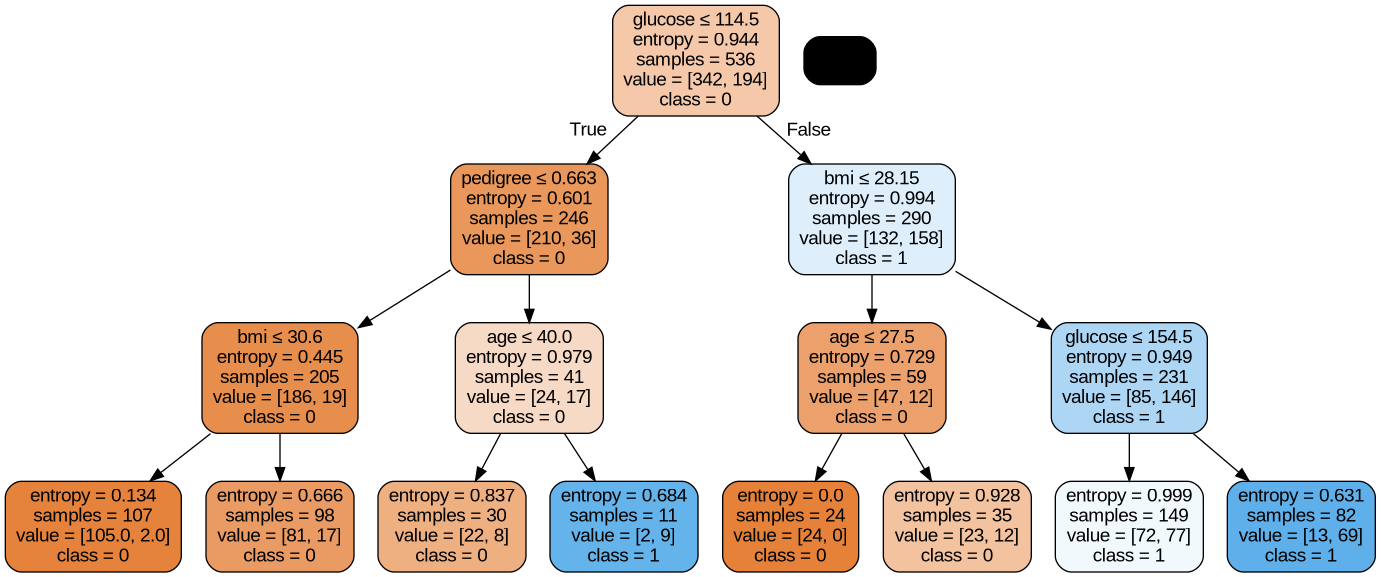

In [ ]:

import pydotplus
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

## Decision Tree Classifier for `Breast_Cancer.csv`

In [ ]:
# Load the Breast_Cancer.csv dataset
breast_cancer_data = pd.read_csv('/content/Breast_Cancer.csv')

print("Breast Cancer Data Head:")
display(breast_cancer_data.head())

print("\nBreast Cancer Data Info:")
breast_cancer_data.info()

Breast Cancer Data Head:


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive



Breast Cancer Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 n

### Preprocessing for `Breast_Cancer.csv`

In [ ]:
# Preprocess 'Status' column (Dead=1, Alive=0)
breast_cancer_data['Status'] = breast_cancer_data['Status'].map({'Dead': 1, 'Alive': 0})

# Identify categorical columns for one-hot encoding (excluding the target 'Status')
categorical_cols = breast_cancer_data.select_dtypes(include=['object']).columns.tolist()
if 'Status' in categorical_cols:
    categorical_cols.remove('Status')

# Apply one-hot encoding
breast_cancer_data_encoded = pd.get_dummies(breast_cancer_data, columns=categorical_cols, drop_first=True)

# Define features and target variable for breast_cancer_data
feature_cols_bc = breast_cancer_data_encoded.columns.drop('Status').tolist()
X_bc = breast_cancer_data_encoded[feature_cols_bc] # Features
y_bc = breast_cancer_data_encoded.Status # Target variable

display(X_bc.head())
display(y_bc.head())

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,...,6th Stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,Grade_1,Grade_2,Grade_3,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive
0,68,4,24,1,60,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True
1,50,35,14,5,62,False,True,True,False,False,...,False,False,False,False,False,True,False,True,True,True
2,58,63,14,7,75,False,True,False,False,False,...,True,False,False,False,False,True,False,True,True,True
3,58,18,2,1,84,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True
4,47,41,3,1,50,False,True,True,False,False,...,False,True,False,False,False,False,True,True,True,True


,Status
0,0
1,0
2,0
3,0
4,0


### Split Data and Train Pruned Model for `Breast_Cancer.csv`

In [ ]:
# Split dataset into training set and test set
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.3, random_state=1) # 70% training and 30% test

# Create a pruned Decision Tree Classifier object
clf_bc = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf_bc = clf_bc.fit(X_bc_train, y_bc_train)

# Predict the response for test dataset
y_bc_pred = clf_bc.predict(X_bc_test)

# Model Accuracy
print("Accuracy for Breast_Cancer.csv:", metrics.accuracy_score(y_bc_test, y_bc_pred))

Accuracy for Breast_Cancer.csv: 0.9048013245033113


### Visualize Pruned Decision Tree for `Breast_Cancer.csv`

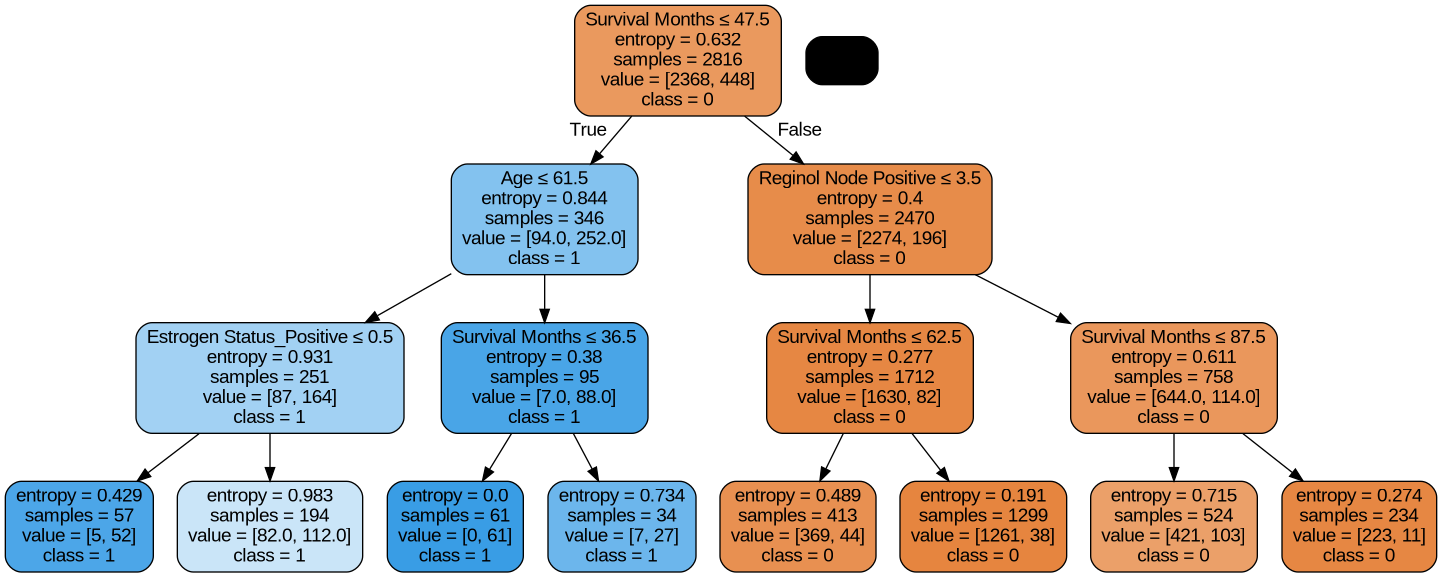

In [ ]:
dot_data_bc = StringIO()
export_graphviz(clf_bc, out_file=dot_data_bc,
                filled=True, rounded=True,
                special_characters=True, feature_names = X_bc.columns.tolist(), class_names=['0','1'])
graph_bc = pydotplus.graph_from_dot_data(dot_data_bc.getvalue())
graph_bc.write_png('breast_cancer_tree.png')
Image(graph_bc.create_png())

## Decision Tree Classifier for `car_data.csv`

In [ ]:
# Load the car_data.csv dataset
car_data = pd.read_csv('/content/car_data.csv')

print("Car Data Head:")
display(car_data.head())

print("\nCar Data Info:")
car_data.info()

Car Data Head:


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0



Car Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


### Preprocessing for `car_data.csv`

In [ ]:
# Preprocess 'Gender' column using one-hot encoding
# Note: 'Gender' is the only object type column besides the target 'Purchased' and identifier 'User ID'.
car_data = pd.get_dummies(car_data, columns=['Gender'], drop_first=True)

# Define features and target variable for car_data
# 'User ID' is typically an identifier and not used as a feature.
feature_cols_car = ['Age', 'AnnualSalary', 'Gender_Male']
X_car = car_data[feature_cols_car] # Features
y_car = car_data.Purchased # Target variable

display(X_car.head())
display(y_car.head())

,Age,AnnualSalary,Gender_Male
0,35,20000,True
1,40,43500,True
2,49,74000,True
3,40,107500,True
4,25,79000,True


,Purchased
0,0
1,0
2,0
3,1
4,0


### Split Data and Train Pruned Model for `car_data.csv`

In [ ]:
# Split dataset into training set and test set
X_car_train, X_car_test, y_car_train, y_car_test = train_test_split(X_car, y_car, test_size=0.3, random_state=1) # 70% training and 30% test

# Create a pruned Decision Tree Classifier object
clf_car = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf_car = clf_car.fit(X_car_train, y_car_train)

# Predict the response for test dataset
y_car_pred = clf_car.predict(X_car_test)

# Model Accuracy
print("Accuracy for car_data.csv:", metrics.accuracy_score(y_car_test, y_car_pred))

Accuracy for car_data.csv: 0.91


### Visualize Pruned Decision Tree for `car_data.csv`

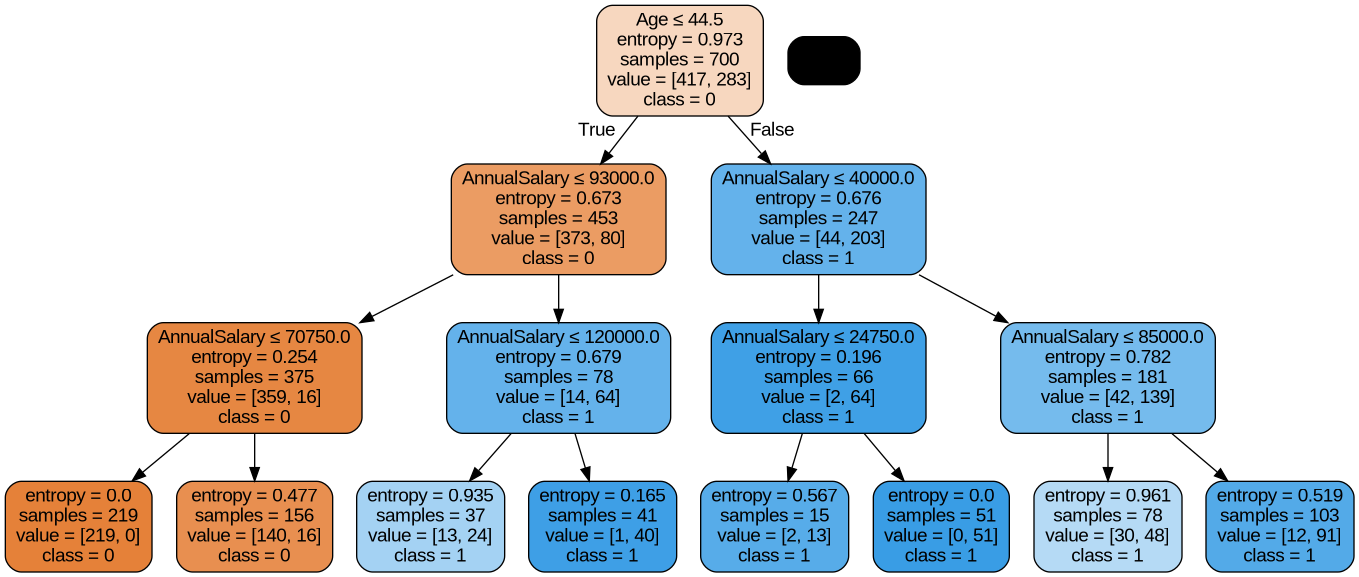

In [ ]:
dot_data_car = StringIO()
export_graphviz(clf_car, out_file=dot_data_car,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols_car, class_names=['0','1'])
graph_car = pydotplus.graph_from_dot_data(dot_data_car.getvalue())
graph_car.write_png('car_data_tree.png')
Image(graph_car.create_png())